# Fine-tuned Qwen3-4B — Chinese Translation Evaluation (Tatoeba Adapters)

Evaluates LoRA-fine-tuned `Qwen3-4B-Instruct-2507` on English↔Chinese round-trip translation and compares it against the base (un-fine-tuned) model's translations.

- **Fine-tuned adapters**: trained on Tatoeba EN↔ZH pairs (see `train_qwen.ipynb`)
- **Baseline**: base Qwen3-4B translations generated by `AI_translation_qwen.ipynb`
- **Metrics**: BLEU, chrF, BERTScore F1

> **Google Colab**: Run on a GPU runtime (Runtime → Change runtime type → T4 GPU).

In [1]:
import sys
!{sys.executable} -m pip install transformers accelerate bitsandbytes datasets pandas peft -q
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --force-reinstall --no-deps "unsloth_zoo @ git+https://github.com/unslothai/unsloth-zoo.git" -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Setup & Load Fine-tuned Model

In [2]:
import os
import gc
import itertools
import torch
import pandas as pd
from datasets import load_dataset
from google.colab import drive
from unsloth import FastLanguageModel

drive.mount("/content/drive")

# === Paths (Tatoeba adapters from train_qwen.ipynb) ===
BASE_DIR = "/content/drive/MyDrive/Coding project/Qwen_Translations"
EN_ZH_ADAPTER = f"{BASE_DIR}/qwen3-zh-ft/final_adapter"
ZH_EN_ADAPTER = f"{BASE_DIR}/qwen3-zh-en-ft/final_adapter"
BASELINE_PATH = f"{BASE_DIR}/lang_results_qwen/chinese.csv"

NUM_ROWS = 500
MAX_SEQ_LENGTH = 2048

# System prompts must match EXACTLY what was used during training
EN_ZH_SYSTEM_PROMPT = ("You are a professional translator. Translate English to "
                       "Mandarin Chinese. Output only the translation, no explanation.")
ZH_EN_SYSTEM_PROMPT = ("You are a professional translator. Translate Mandarin Chinese to "
                       "English. Output only the translation, no explanation.")

print("Configuration ready")
print(f"  EN\u2192ZH adapter: {EN_ZH_ADAPTER}")
print(f"  ZH\u2192EN adapter: {ZH_EN_ADAPTER}")
print(f"  Baseline: {BASELINE_PATH}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuration ready
  EN→ZH adapter: /content/drive/MyDrive/Coding project/Qwen_Translations/qwen3-zh-ft/final_adapter
  ZH→EN adapter: /content/drive/MyDrive/Coding project/Qwen_Translations/qwen3-zh-en-ft/final_adapter
  Baseline: /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/chinese.csv


## Load Data

In [3]:
stream = load_dataset("syvai/finetranslations-chat-da", split="train", streaming=True)
df_raw = pd.DataFrame(itertools.islice(stream, NUM_ROWS))

def extract_user_content(messages):
    for msg in messages:
        if msg.get("role") == "user":
            return msg["content"]
    return None

english_texts = (
    df_raw["messages"]
    .apply(extract_user_content)
    .dropna()
    .reset_index(drop=True)
    .tolist()
)

print(f"Extracted {len(english_texts)} English source texts")

Resolving data files:   0%|          | 0/421 [00:00<?, ?it/s]

Extracted 500 English source texts


## Translation

Round-trip translation using the fine-tuned adapters: English → Chinese → English.

In [4]:
import re

MAX_NEW_TOKENS = 512
BATCH_SIZE = 18


def strip_think_tags(text):
    """Remove Qwen3 <think>...</think> reasoning blocks from output."""
    return re.sub(r'<think>.*?</think>\s*', '', text, flags=re.DOTALL).strip()


def build_prompt(tokenizer, text, system_prompt):
    """Build prompt using the SAME template and system prompt as training."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def translate_batch(model, tokenizer, texts, system_prompt):
    prompts = [build_prompt(tokenizer, t, system_prompt) for t in texts]
    inputs = tokenizer(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_SEQ_LENGTH
    ).to(model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    results = []
    for seq in output_ids:
        new_tokens = seq[input_len:]
        decoded = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        results.append(strip_think_tags(decoded))
    return results


def run_translation_pass(adapter_path, texts, system_prompt, direction_label):
    """Load model+adapter, translate all texts, then free GPU."""
    print(f"\n  Loading adapter: {adapter_path}")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=adapter_path,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side = "left"

    n = len(texts)
    all_results = []
    print(f"  {direction_label} ({n} texts, batch={BATCH_SIZE})")
    for start in range(0, n, BATCH_SIZE):
        batch = texts[start : start + BATCH_SIZE]
        results = translate_batch(model, tokenizer, batch, system_prompt)
        all_results.extend(results)

        for j, (src, tgt) in enumerate(zip(batch, results)):
            print(f"  [{start+j+1}/{n}] {direction_label}: {src[:60]!r}")
            print(f"     → {tgt[:60]!r}")
        print()

    # Free GPU
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  {direction_label} complete, GPU freed")

    return all_results


print(f"Batch size: {BATCH_SIZE}, Max new tokens: {MAX_NEW_TOKENS}")
print("Translation functions ready")

Batch size: 18, Max new tokens: 512
Translation functions ready


In [5]:
import time

OUT_DIR = f"{BASE_DIR}/lang_results_qwen"
out_path = f"{OUT_DIR}/chinese_english_finetuned_tatoeba.csv"

# Delete cached results to force re-evaluation
if os.path.exists(out_path):
    os.remove(out_path)
    print(f"Deleted old cached results")

print(f"{'='*60}")
print(f"Round-trip: EN -> Chinese -> EN  ({len(english_texts)} rows)")
print(f"{'='*60}")

t0 = time.time()

# Pass 1: EN \u2192 ZH (loads model + en_zh adapter, translates, frees GPU)
translated_col = run_translation_pass(
    EN_ZH_ADAPTER, english_texts, EN_ZH_SYSTEM_PROMPT, "English \u2192 Chinese"
)

# Pass 2: ZH \u2192 EN (loads model + zh_en adapter, translates, frees GPU)
back_col = run_translation_pass(
    ZH_EN_ADAPTER, translated_col, ZH_EN_SYSTEM_PROMPT, "Chinese \u2192 English"
)

elapsed = time.time() - t0

ft_df = pd.DataFrame({
    "english_original": english_texts,
    "language": "Chinese",
    "translated": translated_col,
    "back_translated": back_col,
})
ft_df.to_csv(out_path, index=False)
print(f"\nFine-tuned translation complete \u2014 {len(ft_df)} rows in {elapsed:.0f}s")

# Show some examples
for i in range(min(3, len(ft_df))):
    print(f"\n  [{i+1}] EN:  {ft_df['english_original'][i][:80]}")
    print(f"      ZH:  {ft_df['translated'][i][:80]}")
    print(f"      Back: {ft_df['back_translated'][i][:80]}")

Round-trip: EN -> Chinese -> EN  (500 rows)

  Loading adapter: /content/drive/MyDrive/Coding project/Qwen_Translations/qwen3-zh-ft/final_adapter
==((====))==  Unsloth 2026.5.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

unsloth/qwen3-4b-instruct-2507-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  English → Chinese (500 texts, batch=18)


...

  [433/500] Chinese → English: '购物车里没有商品。\n199.00丹麦克朗\n有货\n可爱深蓝色丝绒长裤，尺码104\n文胸\n有猫的连体衣，尺码86\n立即购买 '
     → 'The shopping cart is empty.  \n199.00 DKK  \nIn stock  \nAdorab'
  [434/500] Chinese → English: '<tool_call>'
     → 'Cut the rope.'
  [435/500] Chinese → English: '自2017年8月24日起，denstoredanske.dk網站上的內容編輯和更新已經停止。文章和其他內容以編輯停止時的'
     → 'The content of the denstoredanske.dk website has been edited'
  [436/500] Chinese → English: '描述\n古風心形米珠，紅珊瑚寶石，銀色鏈條長18英寸\n包含姓名、日期或文字，最多可輸入9個字元，包括空格\n附贈一隻絲絨袋\n'
     → 'Description: Ancient heart-shaped beads, red coral, silver c'
  [437/500] Chinese → English: '这是一场显而易见的组合：来自牙买加的忧郁街头歌手与西瓦斯的自动调音演唱的结合。如今，来自韦勒的歌手和来自布隆德比的说唱歌'
     → "It's an obvious combination: a Jamaican grime singer and a S"
  [438/500] Chinese → English: '<tool_call>\n\n<tool_call>\n\n今天是聖誕節前的首個星期日，今天門後藏著一個小小的驚喜。我喜歡被驚喜'
     → '<think>\n\nToday is the first Sunday before Christmas, and the'
  [439/500] Chinese → English: '设计以减少眩光和鬼影\n佳能镜头像差校正设计以减少眩光和...\n电磁光圈设计以减少眩光和...\npicto\n5709

Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [451/500] Chinese → English: '获胜者是Maria Møller！\n我们会联系您以获取正确信息，以便我们能给您寄礼物。\nPusher和Hair Maga'
     → "The winner is Maria Møller! We'll contact you to get the cor"
  [452/500] Chinese → English: '品號：154  \n購買單價：164.00 DKK  \n庫存充足  \n若想讓土壤更通氣，珍珠岩是最佳選擇。  \n珍珠岩類似'
     → 'Item No. 154  \nPrice per unit: 164.00 DKK  \nIn stock  \nPerli'
  [453/500] Chinese → English: '<tool_call>'
     → 'Cut.'
  [454/500] Chinese → English: '所以，要么你非常天真，要么如果你觉得麻烦就远离网络。在这里，你总能找到关于最大的在线交友网站的更新、详细的描述和评论。布'
     → "So, either you're very naive, or if you're not, just stay aw"
  [455/500] Chinese → English: '描述\nNella小姐指甲油，吻青蛙。  \nNella小姐指甲油，吻青蛙，是讓所有女孩都高興的指甲油。女孩們喜歡裝飾指甲，'
     → "Description:  \nNella's fingernail polish, kiss the frog.  \nN"
  [456/500] Chinese → English: '第一个提交评论的人。第一个提问的人。'
     → 'The first person to comment. The first person to ask a quest'
  [457/500] Chinese → English: '- 28\n- 3\n- 2019\n\n在Kulturværftet，DR大乐队与爵士乐界的一位大师共同结束本季的演出。届时，'
     → '- 28\n- 3\n- 2019\n\nAt Kulturværftet, the D

Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [469/500] Chinese → English: '什么都没有，因为几乎没有人会更新那些被开发者放弃的自由软件。“这取决于你所说的普通用户是谁，因为对那些公司来说，这很重要'
     → "There's nothing there because almost no one updates free sof"
  [470/500] Chinese → English: '支持性教学法\n作为一项新措施，支持性教学法在公立学校法中被提出。\n支持性教学法超越了学科教学。支持性教学法的时间应用来补'
     → 'Supportive teaching is a new initiative introduced in the pu'
  [471/500] Chinese → English: '音色很好聽，而且平衡。八個輸入通道結合CD播放機、數位轉換器和擴音器。沒有串流功能，而且觸摸螢幕無法辨識。由於高價位和龐'
     → 'The sound is very pleasing and balanced. The system has eigh'
  [472/500] Chinese → English: '这是个很棒的地方，适合家庭聚餐，而且食物种类丰富。我吃到了很棒的汉堡，还有三个孩子，年龄从4岁到14岁，加上我和我妻子，'
     → 'This is a great place for a family meal and the food is vari'
  [473/500] Chinese → English: '购物车里没有商品。\n250.00 DKK。\n库存充足\n来自Martes Santo的礼盒，包含4款令人兴奋的金酒！这是送'
     → 'The shopping cart is empty.  \n250.00 DKK.  \nIn stock  \nA box'
  [474/500] Chinese → English: 'c - 我在 Windows 上使用 _spawnvp(_P_NOWAIT, ...) 启动了一个子进程。这个子进程通过'
     → "c - I'm spawning a child process on Windows using _spawnvp(_"
  [475/5

## Load Baseline Translations

Load the base (un-fine-tuned) Qwen model's Chinese translations generated by `AI_translation_qwen.ipynb`.

In [14]:
baseline_df = pd.read_csv(BASELINE_PATH)
print(f"Baseline results: {len(baseline_df)} rows")
print(f"Columns: {list(baseline_df.columns)}")
baseline_df.head()

Baseline results: 500 rows
Columns: ['english_original', 'language', 'translated', 'back_translated']


,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Chinese,亿万富翁拉尔斯·拉森终于被允许扩大他的商业帝国。 \n丹麦竞争与消费者局今天批准了拉尔斯·...,The billionaire Lars Larsson finally gets the ...
1,I need my hedge trimmed in my allotment garden...,Chinese,我需要在巴勒鲁普的我的菜园里修剪我的灌木篱笆。篱笆很容易到达，大约170厘米高，需要在一边修...,I need to trim my shrubs in my garden in Balle...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Chinese,Funhouse Katsuragawa \nFunhouse Katsuragawa提供...,Funhouse Katsuragawa \nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Chinese,在鲁德科比恩的欣安莱格鸟巢附近，这些艰难生存的邻居们看到了胜利。许多乌鸦已经迁徙。但最终的胜...,"Near the欣安莱格 bird's nest in Rudokbin, these st..."
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Chinese,报纸 \n摩根汽车公司是世界上现存最古老的私营汽车品牌。自1909年以来，该公司一直持续生...,The newspaper \nMorgan Motor Company is the w...


## Scoring

Free GPU memory, then compute BLEU, chrF, and BERTScore F1 for both baseline and fine-tuned back-translations.

In [15]:
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed for scoring phase")

GPU memory freed for scoring phase


In [16]:
import sys
!{sys.executable} -m pip install sacrebleu bert-score matplotlib seaborn -q

In [17]:
import sacrebleu
from bert_score import score as bert_score
from transformers import RobertaTokenizer

# Unsloth's transformers upgrade removes this method — patch it back
if not hasattr(RobertaTokenizer, "build_inputs_with_special_tokens"):
    def _build_inputs_with_special_tokens(self, token_ids_0, token_ids_1=None):
        cls = [self.cls_token_id]
        sep = [self.sep_token_id]
        if token_ids_1 is None:
            return cls + token_ids_0 + sep
        return cls + token_ids_0 + sep + sep + token_ids_1 + sep
    RobertaTokenizer.build_inputs_with_special_tokens = _build_inputs_with_special_tokens
    print("Patched RobertaTokenizer.build_inputs_with_special_tokens")


def compute_scores(df, label):
    """Compute BLEU, chrF, and BERTScore for a dataframe."""
    df = df.copy()

    # Replace empty/NaN back-translations with placeholder to avoid bert_score crash
    df["back_translated"] = df["back_translated"].fillna("").replace("", "[empty]")

    df["bleu"] = df.apply(
        lambda r: sacrebleu.sentence_bleu(r["back_translated"], [r["english_original"]]).score, axis=1
    )
    df["chrf"] = df.apply(
        lambda r: sacrebleu.sentence_chrf(r["back_translated"], [r["english_original"]]).score, axis=1
    )

    print(f"BERTScore: {label} ({len(df)} rows)...")
    P, R, F1 = bert_score(
        df["back_translated"].tolist(),
        df["english_original"].tolist(),
        lang="en", verbose=False, use_fast_tokenizer=True,
    )
    df["bertscore_precision"] = P.numpy()
    df["bertscore_recall"] = R.numpy()
    df["bertscore_f1"] = F1.numpy()

    print(f"  {label} — BLEU: {df['bleu'].mean():.2f}  chrF: {df['chrf'].mean():.2f}  BERTScore F1: {df['bertscore_f1'].mean():.4f}")
    return df


baseline_scored = compute_scores(baseline_df, "Baseline")
ft_scored = compute_scores(ft_df, "Fine-tuned")

Patched RobertaTokenizer.build_inputs_with_special_tokens
BERTScore: Baseline (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Baseline — BLEU: 22.39  chrF: 56.00  BERTScore F1: 0.9114
BERTScore: Fine-tuned (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Fine-tuned — BLEU: 25.74  chrF: 53.47  BERTScore F1: 0.9127


## Comparison

Side-by-side summary of mean scores and per-sentence differences.

In [21]:
METRICS = ["bleu", "chrf", "bertscore_f1"]

comparison = pd.DataFrame({
    "Baseline (base model)": baseline_scored[METRICS].mean(),
    "Fine-tuned (LoRA)": ft_scored[METRICS].mean(),
})
comparison["Difference"] = comparison["Fine-tuned (LoRA)"] - comparison["Baseline (base model)"]
comparison["Change (%)"] = (comparison["Difference"] / comparison["Baseline (base model)"] * 100).round(2)

print("=== Mean Scores: Base vs Fine-tuned (Chinese) ===")
print(comparison.round(4).to_string())
print()

improved = (comparison["Difference"] > 0).sum()
print(f"Fine-tuned model is better on {improved}/{len(METRICS)} metrics")

=== Mean Scores: Base vs Fine-tuned (Chinese) ===
              Baseline (base model)  Fine-tuned (LoRA)  Difference  Change (%)
bleu                        22.3890            25.7430      3.3540       14.98
chrf                        56.0002            53.4676     -2.5326       -4.52
bertscore_f1                 0.9114             0.9127      0.0012        0.14

Fine-tuned model is better on 2/3 metrics


## Visualisation

Comparative plots: paired box plots per metric, bar chart of mean scores, and histogram of per-sentence score differences.

/tmp/ipykernel_4621/85950607.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4621/85950607.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4621/85950607.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


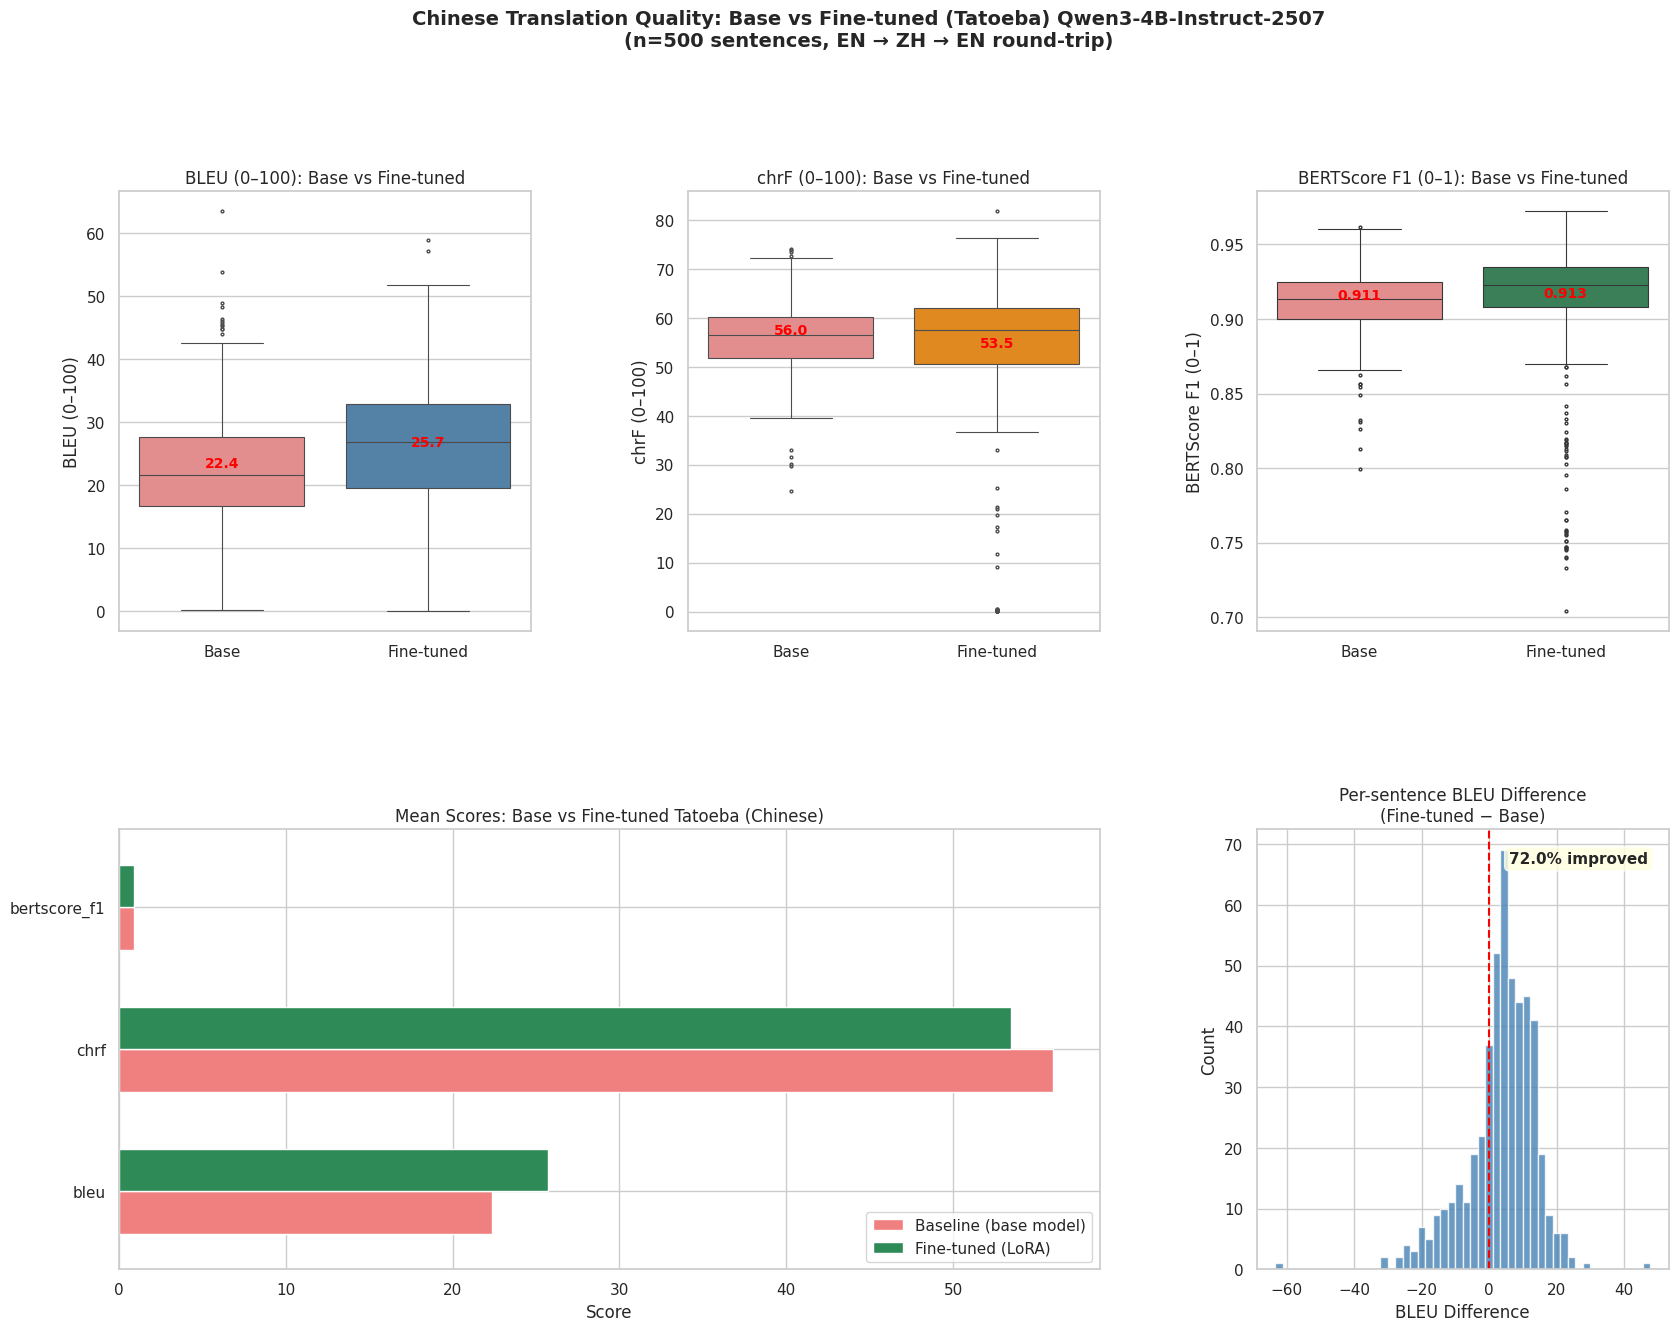

Saved plot to /content/drive/MyDrive/Coding project/Qwen_Translations/translation_quality_finetuned_tatoeba_comparison.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid")

baseline_scored["model"] = "Base"
ft_scored["model"] = "Fine-tuned"
combined = pd.concat([baseline_scored, ft_scored], ignore_index=True)

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

METRIC_INFO = [
    ("bleu",         "BLEU (0\u2013100)",       "steelblue"),
    ("chrf",         "chrF (0\u2013100)",        "darkorange"),
    ("bertscore_f1", "BERTScore F1 (0\u20131)",  "seagreen"),
]

# Row 1: Paired box plots \u2014 base vs fine-tuned for each metric
for col, (metric, label, color) in enumerate(METRIC_INFO):
    ax = fig.add_subplot(gs[0, col])
    sns.boxplot(
        data=combined, x="model", y=metric,
        order=["Base", "Fine-tuned"],
        palette={"Base": "lightcoral", "Fine-tuned": color},
        fliersize=2, linewidth=0.8, ax=ax,
    )
    means = combined.groupby("model")[metric].mean()
    fmt = ".1f" if metric != "bertscore_f1" else ".3f"
    for j, m in enumerate(["Base", "Fine-tuned"]):
        ax.text(j, means[m], f"{means[m]:{fmt}}",
                ha="center", va="bottom", fontsize=10, color="red", fontweight="bold")
    ax.set_title(f"{label}: Base vs Fine-tuned")
    ax.set_xlabel("")
    ax.set_ylabel(label)

# Row 2, col 0-1: Mean scores bar chart
ax4 = fig.add_subplot(gs[1, 0:2])
means_plot = comparison[["Baseline (base model)", "Fine-tuned (LoRA)"]].copy()
means_plot.plot(kind="barh", ax=ax4,
                color=["lightcoral", "seagreen"],
                width=0.6, edgecolor="white")
ax4.set_title("Mean Scores: Base vs Fine-tuned Tatoeba (Chinese)")
ax4.set_xlabel("Score")
ax4.set_ylabel("")
ax4.legend(loc="lower right")

# Row 2, col 2: Histogram of per-sentence BLEU difference (fine-tuned - base)
ax5 = fig.add_subplot(gs[1, 2])
diff_bleu = ft_scored["bleu"].values - baseline_scored["bleu"].values
ax5.hist(diff_bleu, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax5.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax5.set_title("Per-sentence BLEU Difference\n(Fine-tuned \u2212 Base)")
ax5.set_xlabel("BLEU Difference")
ax5.set_ylabel("Count")
pct_improved = (diff_bleu > 0).mean() * 100
ax5.text(0.95, 0.95, f"{pct_improved:.1f}% improved",
         transform=ax5.transAxes, ha="right", va="top",
         fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.suptitle(
    f"Chinese Translation Quality: Base vs Fine-tuned (Tatoeba) Qwen3-4B-Instruct-2507\n"
    f"(n={len(baseline_scored)} sentences, EN \u2192 ZH \u2192 EN round-trip)",
    fontsize=14, fontweight="bold", y=1.01,
)
plot_path = f"{BASE_DIR}/translation_quality_finetuned_tatoeba_comparison.png"
plt.savefig(plot_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved plot to {plot_path}")

## Save Results

In [20]:
ft_scored.to_csv(f"{BASE_DIR}/chinese_finetuned_tatoeba_scored.csv", index=False)
baseline_scored.to_csv(f"{BASE_DIR}/chinese_baseline_scored.csv", index=False)
comparison.to_csv(f"{BASE_DIR}/comparison_base_vs_finetuned_tatoeba.csv")
print(f"Saved scored results to {BASE_DIR}/")

print("\n=== Final Comparison ===")
print(comparison.round(4).to_string())

Saved scored results to /content/drive/MyDrive/Coding project/Qwen_Translations/

=== Final Comparison ===
              Baseline (base model)  Fine-tuned (LoRA)  Difference  Change (%)
bleu                        22.3890            25.7430      3.3540       14.98
chrf                        56.0002            53.4676     -2.5326       -4.52
bertscore_f1                 0.9114             0.9127      0.0012        0.14
